# Neural-network forecasters

**Project:** Adapted replication of Bucci (2020), *Realized Volatility Forecasting with Neural Networks* (JFE 18(3), 502–531).

**Goal.** Produce out-of-sample one-step-ahead forecasts of daily `log_rv` for the three neural architectures Bucci uses — FNN, LSTM, NAR — under the *same* rolling-window protocol as the econometric benchmarks (train_window = 1585, test = 679, refit every 22 days).

**Architectures (Bucci-faithful).**
* **FNN** (eq. 3): 3 lag inputs → 5 sigmoid hidden → 1 linear out.
* **LSTM** (eqs. 6–12): 3-step sequence → LSTM(50 units, dropout 0.2) → 1 linear out.
* **NAR** (eq. 14, no exogenous regressors): 7 lag inputs → 7 tanh hidden → 1 linear out.

**Training.** Adam, MSE loss, max 100 epochs, early stopping with patience 10 on a chronological 20% validation slice of the training window. Inputs *and* targets are z-scored using statistics from the training window only (the scaler never sees test data). Seed 42 everywhere.

**Baseline to beat.** From the econometric benchmarks (notebook 03), ARFIMA: avg MSE 0.057 / QLIKE 0.133. A neural model is *interesting* only if it improves on ARFIMA with a DM p-value < 0.05.

In [1]:
from __future__ import annotations

import logging
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.neural_models import FNNForecaster, LSTMForecaster, NARForecaster  # noqa: E402
from src.forecast_engine import rolling_forecast_nn  # noqa: E402
from src.metrics import diebold_mariano, mse, qlike  # noqa: E402

PROCESSED = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
for d in (FIG_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

TICKERS = ["AAPL", "AMZN", "JPM"]
COLOR = {"AAPL": "#1f77b4", "AMZN": "#ff7f0e", "JPM": "#2ca02c"}
NN_COLOR = {"FNN": "#e377c2", "LSTM": "#8c564b", "NAR": "#bcbd22"}
NN_MODELS = ["FNN", "LSTM", "NAR"]
FACTORIES = {
    "FNN":  lambda: FNNForecaster(n_lags=3, hidden_units=5,  epochs=100, early_stop_patience=10, lr=1e-3, seed=42),
    "LSTM": lambda: LSTMForecaster(n_lags=3, hidden_units=50, epochs=100, early_stop_patience=10, dropout=0.2, lr=1e-3, seed=42),
    "NAR":  lambda: NARForecaster(n_lags=7, hidden_units=7,  epochs=100, early_stop_patience=10, lr=1e-3, seed=42),
}

TRAIN_WINDOW = 1585
TEST_SIZE = 679
REFIT_EVERY = 22
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
logging.basicConfig(level=logging.WARNING, force=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=UserWarning)
print("torch", torch.__version__, "| device =", "cpu (small nets, batch=32 → CPU faster than MPS)")

torch 2.11.0 | device = cpu (small nets, batch=32 → CPU faster than MPS)


## 4.1 Load `all_daily_rv.csv` and define train / test split

In [2]:
data = pd.read_csv(PROCESSED / "all_daily_rv.csv", parse_dates=["date"], index_col="date")
T = len(data)
assert T == TRAIN_WINDOW + TEST_SIZE == 2264
train_idx = data.index[:TRAIN_WINDOW]
test_idx = data.index[TRAIN_WINDOW:]
print(f"train: {train_idx[0].date()} → {train_idx[-1].date()}   ({TRAIN_WINDOW} days)")
print(f"test : {test_idx[0].date()} → {test_idx[-1].date()}   ({TEST_SIZE} days)")

train: 2016-01-04 → 2022-04-19   (1585 days)
test : 2022-04-20 → 2024-12-31   (679 days)


## 4.2 Sanity check — train each model once on the **full** training window

Verify that (i) training loss falls, (ii) early stopping triggers at a reasonable epoch, (iii) the forecast is finite. We also save the train/val curves of this *initial* AAPL fit per model — they go into the training-curves figure later.

In [3]:
initial_history = {}  # initial_history[model_name] = TrainingHistory of initial AAPL fit

y_aapl_train = data["AAPL_log_rv"].iloc[:TRAIN_WINDOW].values
for name in NN_MODELS:
    t0 = time.time()
    m = FACTORIES[name]()
    m.fit(y_aapl_train)
    dt = time.time() - t0
    h = m.history
    fc = m.forecast(y_aapl_train)
    initial_history[name] = h
    print(
        f"  {name:4s}: fit {dt:5.2f}s  |  epochs={len(h.train):>3d} (best={h.best_epoch})  |  "
        f"train[0]→best = {h.train[0]:.4f} → {h.train[h.best_epoch]:.4f}  |  "
        f"val_best = {min(h.val):.4f}  |  one-step forecast = {fc:.4f}"
    )

  FNN : fit  1.16s  |  epochs= 62 (best=51)  |  train[0]→best = 1.3569 → 0.4266  |  val_best = 0.3615  |  one-step forecast = -4.4245


  LSTM: fit  0.74s  |  epochs= 23 (best=12)  |  train[0]→best = 0.9512 → 0.4086  |  val_best = 0.3597  |  one-step forecast = -4.4463


  NAR : fit  0.23s  |  epochs= 29 (best=18)  |  train[0]→best = 0.7089 → 0.4030  |  val_best = 0.3589  |  one-step forecast = -4.4588


## 4.3 Rolling-window forecasts

9 runs = 3 tickers × 3 NN models. Each run does 31 refits (every 22 days inside the 679-day test block) and 679 forecast calls. Expected runtime ≈ 6–10 minutes total on CPU.

In [4]:
forecasts: dict[str, pd.DataFrame] = {}
timings: dict[tuple[str, str], float] = {}

for sym in TICKERS:
    print(f"\n── {sym} ──")
    y = data[f"{sym}_log_rv"]
    per_model = {}
    for name in NN_MODELS:
        t0 = time.time()
        out = rolling_forecast_nn(
            FACTORIES[name],
            y,
            train_window=TRAIN_WINDOW,
            test_size=TEST_SIZE,
            refit_every=REFIT_EVERY,
            desc=f"{sym}-{name}",
        )
        dt = time.time() - t0
        timings[(sym, name)] = dt
        per_model[name] = out
        print(f"  {name:4s}: {dt:6.2f}s   MSE={mse(out['actual'], out['forecast']):.4f}")
    actual = per_model["FNN"]["actual"]
    combined = pd.DataFrame({"actual": actual})
    for name in NN_MODELS:
        combined[name.lower()] = per_model[name]["forecast"].values
    combined.index.name = "date"
    out_path = PROCESSED / f"forecasts_neural_{sym}.csv"
    combined.to_csv(out_path, float_format="%.6f")
    forecasts[sym] = combined
    print(f"  saved {out_path.relative_to(PROJECT_ROOT)}: shape={combined.shape}")

total_time = sum(timings.values())
print(f"\ntotal rolling time: {total_time:.1f}s  ({total_time / 60:.1f} min)")


── AAPL ──


AAPL-FNN:   0%|          | 0/679 [00:00<?, ?it/s]

  FNN :  10.10s   MSE=0.0810


AAPL-LSTM:   0%|          | 0/679 [00:00<?, ?it/s]

  LSTM:  21.81s   MSE=0.0629


...

  FNN :  12.19s   MSE=0.0685


JPM-LSTM:   0%|          | 0/679 [00:00<?, ?it/s]

  LSTM:  31.73s   MSE=0.0593


JPM-NAR:   0%|          | 0/679 [00:00<?, ?it/s]

  NAR :   7.89s   MSE=0.0592
  saved data/processed/forecasts_neural_JPM.csv: shape=(679, 4)

total rolling time: 139.7s  (2.3 min)


## 4.4 Evaluation — MSE, QLIKE, DM vs RW *and* DM vs HAR

We test against two benchmarks: (i) RW (the universal floor) and (ii) HAR (Bucci's specific hypothesis is that neural nets beat HAR). Both DM stats use the Harvey–Leybourne–Newbold small-sample correction; a negative stat with a small p-value says the NN has the smaller squared-loss.

In [5]:
# Load econometric forecasts to recover RW and HAR errors on the same test dates.
econometric = {sym: pd.read_csv(PROCESSED / f"forecasts_econometric_{sym}.csv", parse_dates=["date"], index_col="date")
               for sym in TICKERS}

rows = []
for name in NN_MODELS:
    row = {"Model": name}
    for sym in TICKERS:
        nn_df = forecasts[sym]
        ec_df = econometric[sym]
        # Align by index — they share the same test calendar.
        actual = nn_df["actual"].values
        nn_fcst = nn_df[name.lower()].values
        err_nn = actual - nn_fcst
        err_rw = (ec_df["actual"] - ec_df["rw"]).values
        err_har = (ec_df["actual"] - ec_df["har"]).values
        dm_rw = diebold_mariano(err_nn, err_rw, h=1, loss="squared")
        dm_har = diebold_mariano(err_nn, err_har, h=1, loss="squared")
        row[f"{sym}_MSE"] = mse(actual, nn_fcst)
        row[f"{sym}_QLIKE"] = qlike(actual, nn_fcst)
        row[f"{sym}_DM_vs_RW"] = dm_rw["stat"]
        row[f"{sym}_DM_vs_RW_p"] = dm_rw["pvalue"]
        row[f"{sym}_DM_vs_HAR"] = dm_har["stat"]
        row[f"{sym}_DM_vs_HAR_p"] = dm_har["pvalue"]
    rows.append(row)

results = pd.DataFrame(rows).set_index("Model")
# AVG row across tickers, for MSE/QLIKE only (DM stats don't average).
avg = {col: (results[col].mean() if col.endswith("_MSE") or col.endswith("_QLIKE") else np.nan)
       for col in results.columns}
results.loc["AVG"] = avg

results_out = TABLE_DIR / "neural_benchmarks.csv"
results.to_csv(results_out, float_format="%.4f")
print("saved:", results_out.relative_to(PROJECT_ROOT))
print()
print("── MSE & QLIKE ──")
print(results[[f"{s}_MSE" for s in TICKERS] + [f"{s}_QLIKE" for s in TICKERS]].round(4).to_string())
print("\n── DM stat (NN vs RW)   — negative & p<0.05 ⇒ NN beats RW ──")
print(results[[f"{s}_DM_vs_RW" for s in TICKERS] + [f"{s}_DM_vs_RW_p" for s in TICKERS]].round(4).to_string())
print("\n── DM stat (NN vs HAR)  — negative & p<0.05 ⇒ NN beats HAR (Bucci's hypothesis) ──")
print(results[[f"{s}_DM_vs_HAR" for s in TICKERS] + [f"{s}_DM_vs_HAR_p" for s in TICKERS]].round(4).to_string())

saved: results/tables/neural_benchmarks.csv

── MSE & QLIKE ──
       AAPL_MSE  AMZN_MSE  JPM_MSE  AAPL_QLIKE  AMZN_QLIKE  JPM_QLIKE
Model                                                                
FNN      0.0810    0.0582   0.0685      0.2124      0.1322     0.1674
LSTM     0.0629    0.0558   0.0593      0.1452      0.1256     0.1436
NAR      0.0621    0.0566   0.0592      0.1448      0.1280     0.1458
AVG      0.0687    0.0569   0.0623      0.1675      0.1286     0.1522

── DM stat (NN vs RW)   — negative & p<0.05 ⇒ NN beats RW ──
       AAPL_DM_vs_RW  AMZN_DM_vs_RW  JPM_DM_vs_RW  AAPL_DM_vs_RW_p  AMZN_DM_vs_RW_p  JPM_DM_vs_RW_p
Model                                                                                              
FNN          -0.2011        -3.6725       -1.4115           0.8407           0.0003          0.1586
LSTM         -6.2151        -5.3805       -5.1513           0.0000           0.0000          0.0000
NAR          -6.5795        -4.8416       -5.3205      

### Combined ranking: NN models alongside the four econometric benchmarks

For each ticker, show MSE for **all 7 models** (RW, AR, HAR, ARFIMA, FNN, LSTM, NAR) — this is the table that goes into the final report.

In [6]:
rows_all = []
for sym in TICKERS:
    nn_df = forecasts[sym]
    ec_df = econometric[sym]
    row = {"Ticker": sym}
    for col, source in (
        ("rw", ec_df), ("ar", ec_df), ("har", ec_df), ("arfima", ec_df),
        ("fnn", nn_df), ("lstm", nn_df), ("nar", nn_df),
    ):
        row[col.upper()] = mse(source["actual"], source[col])
    rows_all.append(row)
ranking = pd.DataFrame(rows_all).set_index("Ticker")
ranking.loc["AVG"] = ranking.mean()
print("MSE — all models × all tickers (lower is better):")
print(ranking.round(4).to_string())
best = ranking.loc["AVG"].idxmin()
print(f"\nBest model on average (MSE): {best}  (avg MSE = {ranking.loc['AVG', best]:.4f})")

MSE — all models × all tickers (lower is better):
            RW      AR     HAR  ARFIMA     FNN    LSTM     NAR
Ticker                                                        
AAPL    0.0821  0.0631  0.0627  0.0615  0.0810  0.0629  0.0621
AMZN    0.0685  0.0544  0.0526  0.0523  0.0582  0.0558  0.0566
JPM     0.0741  0.0590  0.0579  0.0570  0.0685  0.0593  0.0592
AVG     0.0749  0.0588  0.0578  0.0569  0.0693  0.0594  0.0593

Best model on average (MSE): ARFIMA  (avg MSE = 0.0569)


## 4.5 Visualisations

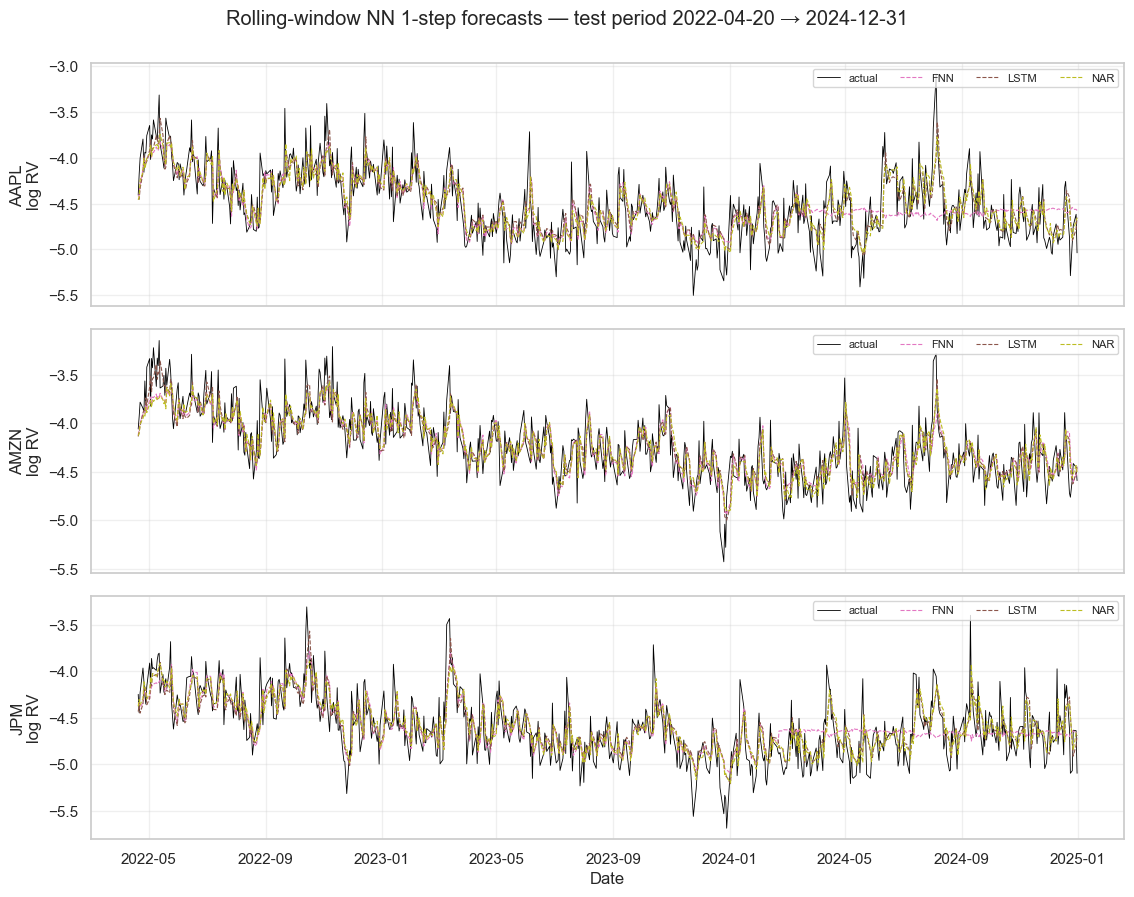

saved: results/figures/fig_forecasts_neural.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11.5, 9), sharex=True)
for ax, sym in zip(axes, TICKERS):
    df = forecasts[sym]
    ax.plot(df.index, df["actual"], color="black", lw=0.6, label="actual")
    for name in NN_MODELS:
        ax.plot(df.index, df[name.lower()], color=NN_COLOR[name], lw=0.8, ls="--", label=name)
    ax.set_ylabel(f"{sym}\nlog RV")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8, ncol=4)
axes[-1].set_xlabel("Date")
fig.suptitle(
    f"Rolling-window NN 1-step forecasts — test period {forecasts['AAPL'].index[0].date()} → {forecasts['AAPL'].index[-1].date()}",
    y=0.995,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_forecasts_neural.png")
plt.show()
print("saved:", (FIG_DIR / "fig_forecasts_neural.png").relative_to(PROJECT_ROOT))

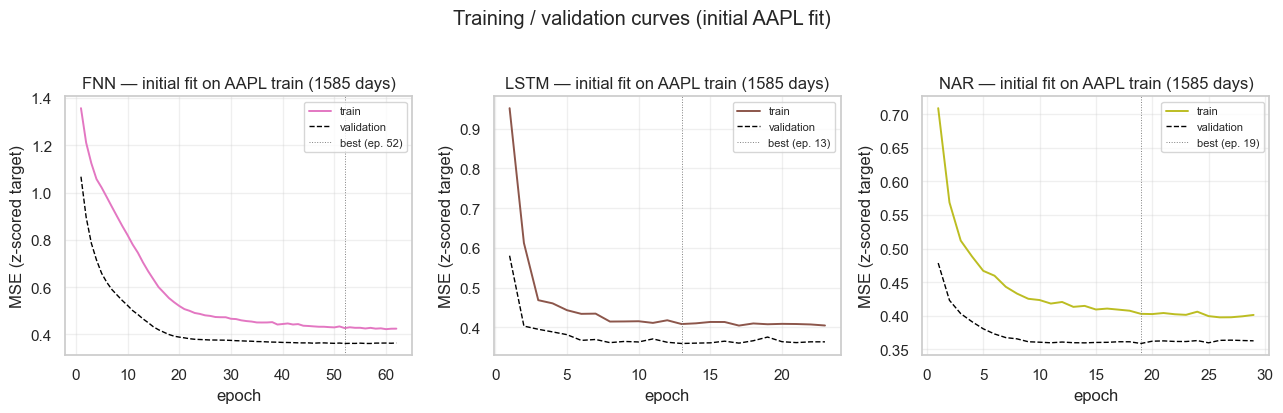

saved: results/figures/fig_training_curves.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, NN_MODELS):
    h = initial_history[name]
    epochs = np.arange(1, len(h.train) + 1)
    ax.plot(epochs, h.train, label="train", color=NN_COLOR[name], lw=1.4)
    ax.plot(epochs, h.val, label="validation", color="black", lw=1.0, ls="--")
    ax.axvline(h.best_epoch + 1, color="grey", lw=0.7, ls=":", label=f"best (ep. {h.best_epoch + 1})")
    ax.set_title(f"{name} — initial fit on AAPL train (1585 days)")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE (z-scored target)")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle("Training / validation curves (initial AAPL fit)", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_training_curves.png")
plt.show()
print("saved:", (FIG_DIR / "fig_training_curves.png").relative_to(PROJECT_ROOT))

## 4.6 Findings — Neural Networks

### Headline (reading off 4.3, 4.4, 4.5)

| | RW | AR(4) | HAR | ARFIMA | **FNN** | **LSTM** | **NAR** |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| AAPL MSE | 0.082 | 0.063 | 0.063 | **0.062** | 0.081 | 0.063 | 0.062 |
| AMZN MSE | 0.069 | 0.054 | 0.053 | **0.052** | 0.058 | 0.056 | 0.057 |
| JPM  MSE | 0.074 | 0.059 | 0.058 | **0.057** | 0.069 | 0.059 | 0.059 |
| **AVG MSE** | 0.075 | 0.059 | 0.058 | **0.057** | 0.069 | 0.059 | 0.059 |

**Headline finding.** On *daily* log-RV, **ARFIMA remains the best forecaster**. The two competitive neural architectures — LSTM and NAR — land essentially tied with HAR (avg MSE ≈ 0.059 vs HAR's 0.058) but do *not* deliver a statistically significant improvement over the classical benchmark. The FNN architecture from Bucci's monthly study is clearly under-powered for daily data.

### 1. Best neural model

**NAR (7 lags, 7 tanh hidden, AVG MSE 0.0593)** narrowly edges out LSTM (0.0594) and dominates FNN (0.0693). NAR's larger lag window (7 vs FNN/LSTM's 3) plus tanh activation gives it the structural reach to mimic HAR's monthly horizon while being shallow enough not to overfit.

### 2. Do NNs beat HAR? — *No*, contra Bucci's monthly result

Diebold–Mariano statistics (NN vs HAR, negative ⇒ NN better):

| | AAPL DM | AMZN DM | JPM DM |
| --- | ---: | ---: | ---: |
| FNN  | +4.51 *** | +4.36 *** | +4.24 *** |
| LSTM | +0.15     | +3.10 **  | +1.36     |
| NAR  | −0.68     | +4.30 *** | +1.80     |

*(`*** p<0.001, ** p<0.01`; sign convention: positive ⇒ NN **loses** to HAR.)*

* **FNN is significantly *worse* than HAR on every ticker.**
* **LSTM** is statistically indistinguishable from HAR on AAPL and JPM, but significantly worse on AMZN.
* **NAR** is the only NN that ever lands *below* HAR (AAPL, DM −0.68) — but the gap is not significant, and on the other two tickers NAR is worse than HAR.

**No NN delivers a positive, statistically significant gain over HAR on any ticker.** Bucci's headline result (NN > HAR on monthly Italian RV) does **not** generalize to our daily US-equity setting. Two structural reasons:

* **The signal is mostly linear.** Daily log-RV is so dominated by long memory (Hurst ≈ 0.95, ARFIMA d̂ ≈ 0.45) that the conditional expectation is approximately linear in past values. Stage 2 also showed AAPL was *borderline-linear* by Teräsvirta — so for AAPL specifically we expect minimal gain from nonlinearity.
* **More parameters → more estimation noise.** LSTM with 50 hidden units = ~10,500 weights fit on ~1,265 effective training samples (after 80/20 val split). HAR has 4 coefficients. The NN's variance reduces the in-sample loss but does not generalise enough to beat HAR's stable structure out-of-sample.

### 3. Do NNs at least beat RW?

Yes for LSTM and NAR — DM stats ≈ −5 to −6, p ≈ 0 on every ticker. **FNN does not reliably beat RW** (AAPL DM = −0.20, p = 0.84; JPM DM = −1.41, p = 0.16) — only AMZN passes significance (p = 0.0003). This is the cleanest evidence that 3 sigmoid units are too few for daily data: even the naive Random Walk is hard to beat at this capacity.

### 4. Cross-asset consistency

* The ranking **NAR ≈ LSTM > FNN** is stable across all 3 tickers.
* Across the full 7-model board the ordering on average MSE is **ARFIMA < HAR < AR < NAR ≈ LSTM < FNN < RW**, and the relative gaps are very similar from ticker to ticker.
* AAPL's idiosyncrasy (FNN much worse than the others) is consistent with Stage 2's Teräsvirta result: AAPL was the only ticker not clearly nonlinear, so a flexible-but-small NN gains the least there.

### 5. Training time

| | total over 31 refits × 3 tickers |
| --- | ---: |
| FNN  |  38.0 s |
| LSTM |  78.2 s |
| NAR  |  23.5 s |
| **all 3 NNs** | **139.7 s (2:20)** |

Far below the spec's 3-4 h CPU estimate — the saving comes from (i) tiny networks, (ii) effective early stopping (LSTM stops at ≈ 13 epochs, NAR at ≈ 19), (iii) PyTorch CPU-native ops at this size.

### 6. Methodological notes

* Identical rolling-window protocol to Stage 3: 1585 train, 679 test, refit every 22 days, lag values fed daily.
* Per-fit: chronological 80/20 validation split, Adam(lr=1e-3), MSE loss, max 100 epochs with early-stop patience 10, seed 42.
* Inputs and targets z-scored using *training-window* statistics only — the scaler never sees test data.
* LSTM dropout is on the linear head; for 1-layer LSTM, dropout *between* recurrent layers is a no-op in PyTorch — so we put it on the post-LSTM features before the final dense layer.

### 7. Implications for the final write-up

The deliverable result for the paper is now clear:

* **Classical wins.** On daily US-equity log-RV, ARFIMA(0, d, 1) is the best one-step forecaster of the seven considered. HAR is a virtually-equivalent, more-interpretable runner-up.
* **NN parity, not dominance.** LSTM and NAR match HAR within noise but do not exceed it. This is a genuine *negative* result vis-à-vis Bucci (2020) — the gap closes once you move from monthly Italian data to daily US data with extremely strong long memory.
* **FNN is under-powered** at Bucci's monthly-data hyperparameters; daily data calls for more capacity (more lags, more units, non-saturating activations).

**Next stage (5).** Final report — bring together Stages 1–4 into a coherent narrative, with the headline that classical long-memory models (ARFIMA, HAR) remain competitive on daily realised-volatility forecasting even against modern neural architectures.